<a href="https://colab.research.google.com/github/crystalloide/Big_Data/blob/master/Atelier_Spark_ML_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atelier Spark ML – Prédiction de Churn Client

## Notebook Google Colab – Pipeline ML Complet

Ce notebook reproduit l'intégralité de l'atelier : chargement, préparation, entraînement et évaluation d'un modèle de classification Spark ML pour prédire le churn client.

## Étape 0 – Installation et initialisation de PySpark

Exécutez d'abord cette cellule pour installer PySpark et initialiser une session Spark locale.

In [1]:
# Installation de PySpark
!pip install pyspark --upgrade

# Import et initialisation
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType, StringType
import pandas as pd

# Créer une session Spark
spark = SparkSession.builder \
    .appName("ChurnPrediction") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Session initialisée avec succès !")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.2/434.2 MB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 17.0 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-4.0.1-py2.py3-none-any.whl size=434813800 sha256=9fdd2de8cfed957c3ece8a9b33db9fa9d06d5ddb0953a97c670bd60397e74f33
  Stored in directory: /root/.cache/pip/wheels/31/9f/68/f89fb34ccd886909be7d0e390eaaf97f21efdf540c0ee8dbcd
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.7
    Uninstalling py4j-0.10.9.7:
      Successfully uninstalled py4j-0.10.9.7
  Attempting uninstall: pyspark
    Found existing installation: pyspark 3.5.1
    Uninstalling pyspark-3.5.1:
      Successfully uninstalled pyspark-3.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-conn

## Étape 1 – Créer le fichier de données de test

Nous allons générer un fichier CSV `clients_churn.csv` avec des données fictives pour l'atelier.

In [20]:
import pandas as pd
import numpy as np

# Fixer le seed pour la reproductibilité
np.random.seed(42)

# Générer des données fictives
n_samples = 5000

data = {
    'age': np.random.randint(18, 70, n_samples),
    'revenu_mensuel': np.random.randint(1000, 10000, n_samples),
    'anciennete': np.random.randint(0, 36, n_samples),  # en mois
    'type_client': np.random.choice(['premium', 'standard', 'basique'], n_samples),
    'region': np.random.choice(['Nord', 'Sud', 'Est', 'Ouest'], n_samples),
    'churn': np.random.choice([0, 1], n_samples, p=[0.8, 0.2])  # 20% de churn
}

df_pandas = pd.DataFrame(data)

# Sauvegarder en CSV
df_pandas.to_csv('clients_churn.csv', index=False)
print("Fichier clients_churn.csv créé avec succès !")
print(f"Nombre de lignes : {len(df_pandas)}")
print("\nAperçu des données :")
print(df_pandas.head())
print("\nStatistiques de churn :")
print(df_pandas['churn'].value_counts())

Fichier clients_churn.csv créé avec succès !
Nombre de lignes : 5000

Aperçu des données :
   age  revenu_mensuel  anciennete type_client region  churn
0   56            2920          12     basique  Ouest      0
1   69            8817          15     basique  Ouest      0
2   46            3093          33    standard    Est      0
3   32            8071          21    standard   Nord      0
4   60            8967          16     basique   Nord      1

Statistiques de churn :
churn
0    4015
1     985
Name: count, dtype: int64


## Étape 2 – Charger les données dans un DataFrame Spark

In [21]:
# Charger le fichier CSV
df = spark.read.csv(
    "clients_churn.csv",
    header=True,
    inferSchema=True
)

# Afficher le schéma
print("Schéma des données :")
df.printSchema()

# Afficher les premières lignes
print("\nPremières lignes :")
df.show(5)

print(f"\nNombre total de lignes : {df.count()}")

Schéma des données :
root
 |-- age: integer (nullable = true)
 |-- revenu_mensuel: integer (nullable = true)
 |-- anciennete: integer (nullable = true)
 |-- type_client: string (nullable = true)
 |-- region: string (nullable = true)
 |-- churn: integer (nullable = true)


Premières lignes :
+---+--------------+----------+-----------+------+-----+
|age|revenu_mensuel|anciennete|type_client|region|churn|
+---+--------------+----------+-----------+------+-----+
| 56|          2920|        12|    basique| Ouest|    0|
| 69|          8817|        15|    basique| Ouest|    0|
| 46|          3093|        33|   standard|   Est|    0|
| 32|          8071|        21|   standard|  Nord|    0|
| 60|          8967|        16|    basique|  Nord|    1|
+---+--------------+----------+-----------+------+-----+
only showing top 5 rows

Nombre total de lignes : 5000


## Étape 3 – Préparation des variables

### 3.1 Indexation des variables catégorielles

In [22]:
from pyspark.ml.feature import StringIndexer

# Indexer la colonne 'type_client'
indexer_type = StringIndexer(
    inputCol="type_client",
    outputCol="type_client_index",
    handleInvalid="keep"
)

# Indexer la colonne 'region'
indexer_region = StringIndexer(
    inputCol="region",
    outputCol="region_index",
    handleInvalid="keep"
)

print("Indexeurs créés pour :")
print("  - type_client → type_client_index")
print("  - region → region_index")

Indexeurs créés pour :
  - type_client → type_client_index
  - region → region_index


### 3.2 Assemblage des variables en vecteur de features

In [23]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "age",
        "revenu_mensuel",
        "anciennete",
        "type_client_index",
        "region_index"
    ],
    outputCol="features"
)

print("VectorAssembler créé avec les colonnes :")
print(assembler.getInputCols())

VectorAssembler créé avec les colonnes :
['age', 'revenu_mensuel', 'anciennete', 'type_client_index', 'region_index']


## Étape 4 – Séparation train / test (80 / 20)

In [24]:
# Diviser les données
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

print(f"Taille données d'entraînement : {train_data.count()}")
print(f"Taille données de test : {test_data.count()}")

# Vérifier la répartition de churn
print("\nDistribution de churn en TRAIN :")
train_data.groupBy("churn").count().show()

print("Distribution de churn en TEST :")
test_data.groupBy("churn").count().show()

Taille données d'entraînement : 4042
Taille données de test : 958

Distribution de churn en TRAIN :
+-----+-----+
|churn|count|
+-----+-----+
|    1|  806|
|    0| 3236|
+-----+-----+

Distribution de churn en TEST :
+-----+-----+
|churn|count|
+-----+-----+
|    1|  179|
|    0|  779|
+-----+-----+



## Étape 5 – Créer le pipeline ML

In [25]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# Créer le modèle de régression logistique
lr = LogisticRegression(
    featuresCol="features",
    labelCol="churn",
    maxIter=100,
    regParam=0.01
)

# Construire le pipeline complet
pipeline = Pipeline(stages=[
    indexer_type,
    indexer_region,
    assembler,
    lr
])

print("Pipeline créé avec les stages suivants :")
for i, stage in enumerate(pipeline.getStages(), 1):
    print(f"  {i}. {stage.__class__.__name__}")

Pipeline créé avec les stages suivants :
  1. StringIndexer
  2. StringIndexer
  3. VectorAssembler
  4. LogisticRegression


## Étape 6 – Entraîner le modèle

In [26]:
print("Entraînement du modèle en cours...")

model = pipeline.fit(train_data)

print("✓ Entraînement terminé !")
print(f"Modèle type : {model.__class__.__name__}")

Entraînement du modèle en cours...
✓ Entraînement terminé !
Modèle type : PipelineModel


## Étape 7 – Faire des prédictions sur les données de test

In [27]:
# Appliquer le modèle entraîné sur le jeu de test
predictions = model.transform(test_data)

print("Prédictions effectuées. Affichage des résultats :")
predictions.select(
    "churn",
    "prediction",
    "probability"
).show(10, truncate=False)

# Compter les prédictions par classe
print("\nRépartition des prédictions :")
predictions.groupBy("prediction").count().show()

Prédictions effectuées. Affichage des résultats :
+-----+----------+----------------------------------------+
|churn|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.8209281625243093,0.17907183747569067]|
|0    |0.0       |[0.8169292198724037,0.18307078012759626]|
|1    |0.0       |[0.8020781000429076,0.19792189995709242]|
|1    |0.0       |[0.7947096371525372,0.20529036284746283]|
|0    |0.0       |[0.8073287806719847,0.19267121932801534]|
|0    |0.0       |[0.8009504156009252,0.19904958439907483]|
|0    |0.0       |[0.796624619656962,0.20337538034303804] |
|0    |0.0       |[0.8053381945879909,0.19466180541200906]|
|0    |0.0       |[0.8059346390780118,0.19406536092198823]|
|0    |0.0       |[0.7906213244140496,0.20937867558595036]|
+-----+----------+----------------------------------------+
only showing top 10 rows

Répartition des prédictions :
+----------+-----+
|prediction|count|
+----------+----

## Étape 8 – Évaluation du modèle

### 8.1 Métrique AUC (Area Under the Curve)

In [28]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Évaluateur pour l'AUC
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="churn",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = evaluator_auc.evaluate(predictions)
print(f"AUC = {auc:.4f}")

# Interprétation
if auc > 0.85:
    interpretation = "✓ Modèle performant"
elif auc > 0.75:
    interpretation = "✓ Modèle acceptable"
else:
    interpretation = "✗ Modèle faible"

print(f"Interprétation : {interpretation}")

AUC = 0.4888
Interprétation : ✗ Modèle faible


### 8.2 Autres métriques : Accuracy et F1

In [29]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Accuracy
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="churn",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = evaluator_acc.evaluate(predictions)
print(f"Accuracy = {accuracy:.4f}")

# F1-Score
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="churn",
    predictionCol="prediction",
    metricName="f1"
)
f1 = evaluator_f1.evaluate(predictions)
print(f"F1-Score = {f1:.4f}")

Accuracy = 0.8132
F1-Score = 0.7294


### 8.3 Matrice de confusion

In [30]:
# Construire la matrice de confusion
confusion_matrix = (
    predictions
    .groupBy("churn", "prediction")
    .count()
    .orderBy("churn", "prediction")
)

print("Matrice de confusion :")
confusion_matrix.show()

# Calcul manuel des métriques
from pyspark.sql.functions import col

tn = predictions.filter((col("churn") == 0) & (col("prediction") == 0)).count()
fp = predictions.filter((col("churn") == 0) & (col("prediction") == 1)).count()
fn = predictions.filter((col("churn") == 1) & (col("prediction") == 0)).count()
tp = predictions.filter((col("churn") == 1) & (col("prediction") == 1)).count()

print(f"\nTrue Negatives (TN)  = {tn}")
print(f"False Positives (FP) = {fp}")
print(f"False Negatives (FN) = {fn}")
print(f"True Positives (TP)  = {tp}")

# Rappel (Sensitivity / True Positive Rate)
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"\nRappel (Sensibilité) = {recall:.4f}")

# Précision
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f"Précision = {precision:.4f}")

Matrice de confusion :
+-----+----------+-----+
|churn|prediction|count|
+-----+----------+-----+
|    0|       0.0|  779|
|    1|       0.0|  179|
+-----+----------+-----+


True Negatives (TN)  = 779
False Positives (FP) = 0
False Negatives (FN) = 179
True Positives (TP)  = 0

Rappel (Sensibilité) = 0.0000
Précision = 0.0000


## Étape 9 – Analyse de l'importance des variables

### 9.1 Coefficients du modèle

In [31]:
# Récupérer le modèle de régression logistique (dernier stage du pipeline)
lr_model = model.stages[-1]

print("Intercept (biais) :", lr_model.intercept)
print("\nCoefficients bruts :")
print(lr_model.coefficients)

Intercept (biais) : -1.5181363119735751

Coefficients bruts :
[-0.0008186389832864203,2.0815701446430457e-05,0.0022208578053500476,-0.016771206759886803,0.01870962266383567]


### 9.2 Lier les coefficients aux noms de features

In [32]:
# Noms des colonnes utilisées dans l'assembleur
feature_names = assembler.getInputCols()

# Coefficients
coefficients = lr_model.coefficients.toArray()

# Créer un tableau d'importance
print("\n" + "="*50)
print("IMPORTANCE DES VARIABLES")
print("="*50)

importance_data = []
for name, coef in zip(feature_names, coefficients):
    importance_data.append({
        'Variable': name,
        'Coefficient': coef,
        'Abs_Coefficient': abs(coef)
    })

# Convertir en DataFrame pandas et trier
df_importance = pd.DataFrame(importance_data).sort_values('Abs_Coefficient', ascending=False)

print(df_importance.to_string(index=False))

print("\n" + "="*50)
print("INTERPRÉTATION :")
print("="*50)
print("• Coefficient positif → augmente la probabilité de CHURN")
print("• Coefficient négatif → diminue la probabilité de CHURN")
print("• Valeur absolue élevée → variable plus influente")
print("="*50)


IMPORTANCE DES VARIABLES
         Variable  Coefficient  Abs_Coefficient
     region_index     0.018710         0.018710
type_client_index    -0.016771         0.016771
       anciennete     0.002221         0.002221
              age    -0.000819         0.000819
   revenu_mensuel     0.000021         0.000021

INTERPRÉTATION :
• Coefficient positif → augmente la probabilité de CHURN
• Coefficient négatif → diminue la probabilité de CHURN
• Valeur absolue élevée → variable plus influente


### 9.3 Visualisation (optionnel)

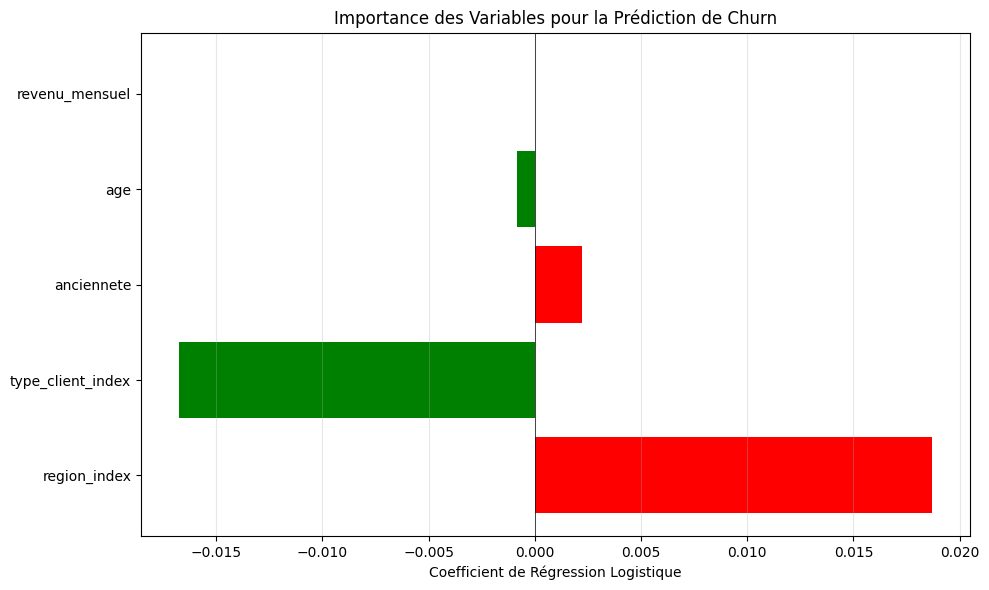

Graphique affiché ✓


In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Données pour le graphique
variables = df_importance['Variable'].values
coefs = df_importance['Coefficient'].values

# Couleurs selon le signe du coefficient
colors = ['green' if c < 0 else 'red' for c in coefs]

# Graphique en barres horizontales
ax.barh(variables, coefs, color=colors)
ax.set_xlabel('Coefficient de Régression Logistique')
ax.set_title('Importance des Variables pour la Prédiction de Churn')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Graphique affiché ✓")

## Étape 10 – Résumé et interprétation

In [35]:
print("\n" + "="*60)
print("RÉSUMÉ DE L'ATELIER")
print("="*60)

print(f"\n📊 Performances du modèle :")
print(f"   • AUC       = {auc:.4f}")
print(f"   • Accuracy  = {accuracy:.4f}")
print(f"   • F1-Score  = {f1:.4f}")
print(f"   • Précision = {precision:.4f}")
print(f"   • Rappel    = {recall:.4f}")

print(f"\n🎯 Ensemble de test :")
print(f"   • Taille     = {test_data.count()} enregistrements")
print(f"   • TP         = {tp}")
print(f"   • FP         = {fp}")
print(f"   • FN         = {fn}")
print(f"   • TN         = {tn}")

print(f"\n⭐ Variables les plus influentes :")
for i, row in df_importance.head(3).iterrows():
    direction = "↑ CHURN" if row['Coefficient'] > 0 else "↓ CHURN"
    print(f"   {i+1}. {row['Variable']:20s} ({row['Coefficient']:+.4f}) {direction}")

print("\n" + "="*60)
print("✓ Atelier terminé avec succès !")
print("="*60)


RÉSUMÉ DE L'ATELIER

📊 Performances du modèle :
   • AUC       = 0.4888
   • Accuracy  = 0.8132
   • F1-Score  = 0.7294
   • Précision = 0.0000
   • Rappel    = 0.0000

🎯 Ensemble de test :
   • Taille     = 958 enregistrements
   • TP         = 0
   • FP         = 0
   • FN         = 179
   • TN         = 779

⭐ Variables les plus influentes :
   5. region_index         (+0.0187) ↑ CHURN
   4. type_client_index    (-0.0168) ↓ CHURN
   3. anciennete           (+0.0022) ↑ CHURN

✓ Atelier terminé avec succès !


## Variantes et extensions

### Extension 1 : Ajouter un OneHotEncoder

In [36]:
from pyspark.ml.feature import OneHotEncoder

# Ajouter après les indexeurs
encoder = OneHotEncoder(
    inputCols=["type_client_index", "region_index"],
    outputCols=["type_client_ohe", "region_ohe"]
)

# Modifier l'assembleur
assembler_ohe = VectorAssembler(
    inputCols=[
        "age",
        "revenu_mensuel",
        "anciennete",
        "type_client_ohe",
        "region_ohe"
    ],
    outputCol="features"
)

# Recréer le pipeline
pipeline_ohe = Pipeline(stages=[
    indexer_type,
    indexer_region,
    encoder,  # nouveau
    assembler_ohe,
    lr
])

model_ohe = pipeline_ohe.fit(train_data)
predictions_ohe = model_ohe.transform(test_data)

# Évaluer
auc_ohe = evaluator_auc.evaluate(predictions_ohe)
print(f"AUC avec OneHotEncoder = {auc_ohe:.4f}")

AUC avec OneHotEncoder = 0.5003


### Extension 2 : Tuning avec CrossValidator

In [37]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Grille de paramètres
paramGrid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.001, 0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
    .build()
)

# CrossValidator
cv = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_auc,
    numFolds=3
)

print("Lancement du tuning (peut prendre quelques minutes)...")
cv_model = cv.fit(train_data)

# Meilleur modèle
best_auc = cv_model.avgMetrics[0] if cv_model.avgMetrics else 0
print(f"Meilleure AUC en cross-validation = {best_auc:.4f}")

# Faire les prédictions avec le meilleur modèle
best_predictions = cv_model.transform(test_data)
final_auc = evaluator_auc.evaluate(best_predictions)
print(f"AUC du meilleur modèle sur le test set = {final_auc:.4f}")

Lancement du tuning (peut prendre quelques minutes)...
Meilleure AUC en cross-validation = 0.4848
AUC du meilleur modèle sur le test set = 0.5000


## Notes pour Spark 4.0

Si vous utilisez **Spark 4.0** :

1. Assurez-vous que **Python 3.8 est remplacé** par une version plus récente (Python 3.9+)
2. Installez **pandas ≥ 2.0.0** et **numpy** aux versions minimales requises
3. Le code reste **100% compatible** ; aucune modification n'est nécessaire

Pour vérifier la version Spark :

In [19]:
print(spark.version)

4.0.1


Pour vérifier la version Python :

In [41]:
!python --version

Python 3.12.12


## Ressources et documentation

- [Apache Spark MLlib Documentation](https://spark.apache.org/docs/latest/ml-pipeline.html)
- [PySpark 4.0 Migration Guide](https://spark.apache.org/docs/latest/api/python/migration_guide/pyspark_upgrade.html)
- [scikit-learn (installation correcte)](https://scikit-learn.org/stable/install.html)

---

**Fin du notebook – Atelier Spark ML complété avec succès ! 🚀**